# Relativistic Quantum Scattering Simulation (CUDA Wrapper)

This notebook provides a Python interface to the CUDA-accelerated FDTD solver for the Relativistic Schrödinger Equation. 
It solves the steady-state scattering problem $\nabla^2 \psi + k(r)^2 \psi = 0$ by simulating the time-evolution of a continuous wave source until it reaches equilibrium.

**Physics:**
The solver simulates a relativistic electron beam with energy $E = mc^2 + T$ scattering off a static potential $V(r)$.
The effective potential seen by the simulation is derived from the relativistic dispersion relation $p^2 c^2 = (E-V)^2 - m^2 c^4$.

**Usage:**
1. Define your potential map $V(x,y)$ in Python.
2. Run the simulation wrapper.
3. Visualize the resulting Scattered Wave Intensity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os

%matplotlib widget 

# Configuration (Must match CUDA code parameters)
NX = 640
NY = 360
XMIN = -2.0
XMAX = 2.0
YMIN = -1.0
YMAX = 1.0
SOL_LIGHT = 137.0
MASS_PART = 1.0
E_KINETIC = 300.0
# Total Energy
E_TOTAL = MASS_PART * SOL_LIGHT**2 + E_KINETIC
# P_INF used to determine simulation energy scale
P_INF = np.sqrt(E_TOTAL**2 - (MASS_PART * SOL_LIGHT**2)**2) / SOL_LIGHT
E_SIM = 0.5 * P_INF**2

print(f"Simulation Energy Scale: {E_SIM:.2f} au")
print(f"Momentum k: {P_INF:.2f} au")

Simulation Energy Scale: 302.40 au
Momentum k: 24.59 au


## 1. Define Your Potential
Create a function that returns the potential $V(x,y)$.
The solver expects the *relativistic effective potential* logic to be handled internally. 
**Input here is the PHYSICAL potential V(r) (e.g. Coulomb, Square Well).**

Example: Two Atoms (Diatomic Molecule)

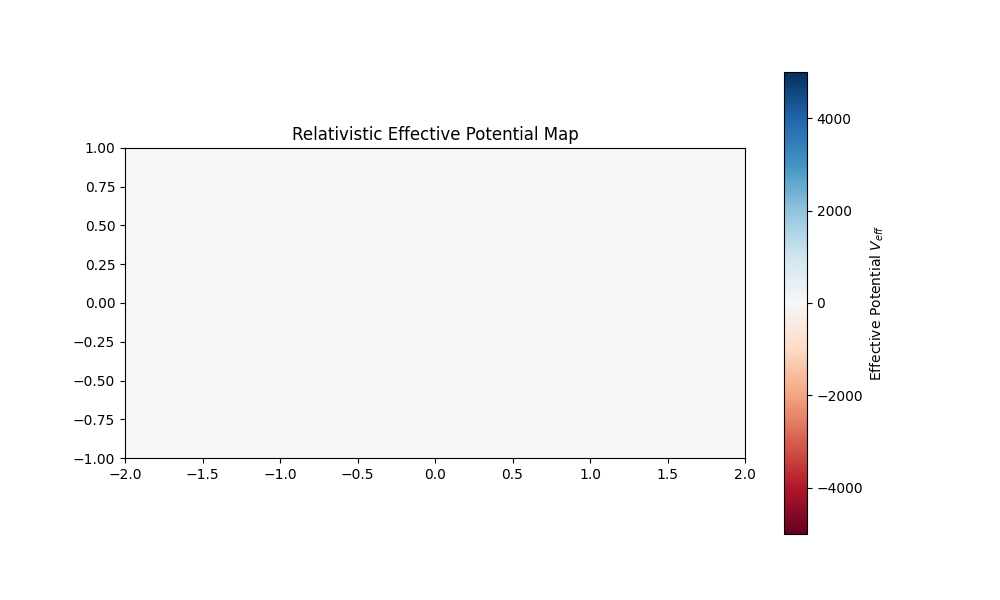

In [2]:
def create_potential_map(nx, ny):
    x = np.linspace(XMIN, XMAX, nx)
    y = np.linspace(YMIN, YMAX, ny)
    X, Y = np.meshgrid(x, y)
    
    # --- USER DEFINED POTENTIAL ---
    
    # 1. Single Atom
    r1 = np.sqrt((X - 0.0)**2 + (Y - 0.0)**2 + 0.05**2)
    
    Z = 0.0 # Atomic Charge
    V_phys = -Z/r1
    
    # ------------------------------
    
    # Convert Physical Potential to Effective Simulation Potential V_eff
    # k^2(r) = [(E-V)^2 - m^2c^4] / c^2
    term1 = (E_TOTAL - V_phys)
    term2 = MASS_PART * SOL_LIGHT**2
    k2_local = (term1**2 - term2**2) / (SOL_LIGHT**2)
    
    # V_eff = E_SIM - 0.5 * k^2
    V_eff = E_SIM - 0.5 * k2_local
    
    return V_eff.astype(np.float32)

V_map = create_potential_map(NX, NY)

plt.figure(figsize=(10,6))
plt.imshow(V_map, extent=[XMIN, XMAX, YMIN, YMAX], cmap='RdBu', vmin=-5000, vmax=5000)
plt.colorbar(label='Effective Potential $V_{eff}$')
plt.title("Relativistic Effective Potential Map")
plt.show()

## 2. Run Simulation
Write the potential to disk, call the CUDA solver, and load the result.

In [3]:
# 1. Write Potential
with open("potential.bin", "wb") as f:
    f.write(np.array([NX, NY], dtype=np.int32).tobytes())
    f.write(V_map.tobytes())
print("Saved potential.bin")

# 2. Run CUDA Solver (with snapshots)
N_FRAMES = 800
STEPS_PER_FRAME = 100
SNAPSHOT_COUNT = 40
cmd = ["./schrodinger_atomic_cuda", str(N_FRAMES), str(STEPS_PER_FRAME), str(SNAPSHOT_COUNT)]
print("Running:", ' '.join(cmd))
try:
    result = subprocess.run(cmd, check=True, capture_output=True, text=True)
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print("Error Running Simulation:")
    print(e.stderr)

# 3. Load snapshots.bin and demodulate
snap_file = 'snapshots.bin'
snapshots = []
with open(snap_file, 'rb') as f:
    nx = np.frombuffer(f.read(4), dtype=np.int32)[0]
    ny = np.frombuffer(f.read(4), dtype=np.int32)[0]
    M = np.frombuffer(f.read(4), dtype=np.int32)[0]
    dt_file = np.frombuffer(f.read(4), dtype=np.float32)[0]
    E_sim_file = np.frombuffer(f.read(4), dtype=np.float32)[0]
    for m in range(M):
        t = np.frombuffer(f.read(4), dtype=np.float32)[0]
        phi = np.frombuffer(f.read(nx*ny*4), dtype=np.float32).reshape((ny,nx))
        psi = np.frombuffer(f.read(nx*ny*4), dtype=np.float32).reshape((ny,nx))
        snapshots.append((t, phi, psi))
print(f"Loaded {len(snapshots)} snapshots (dt file={dt_file}, E_sim={E_sim_file})")

# Demodulate and average to obtain complex steady amplitude
A = np.zeros_like(snapshots[0][1], dtype=np.complex128)
for t, phi_s, psi_s in snapshots:
    psi_c = phi_s + 1j*psi_s
    A += psi_c * np.exp(1j * E_sim_file * t)
A /= len(snapshots)
intensity = np.abs(A)**2

Saved potential.bin
Running: ./schrodinger_atomic_cuda 800 100 40
Initializing CUDA Atomic Simulation (User Potential)...
Run: N_FRAMES=800, STEPS_PER_FRAME=100, SNAPSHOT_COUNT=40
Progress: 0 / 800 frames
Progress: 20 / 800 frames
Progress: 40 / 800 frames
Progress: 60 / 800 frames
Progress: 80 / 800 frames
Progress: 100 / 800 frames
Progress: 120 / 800 frames
Progress: 140 / 800 frames
Progress: 160 / 800 frames
Progress: 180 / 800 frames
Progress: 200 / 800 frames
Progress: 220 / 800 frames
Progress: 240 / 800 frames
Progress: 260 / 800 frames
Progress: 280 / 800 frames
Progress: 300 / 800 frames
Progress: 320 / 800 frames
Progress: 340 / 800 frames
Progress: 360 / 800 frames
Progress: 380 / 800 frames
Progress: 400 / 800 frames
Progress: 420 / 800 frames
Progress: 440 / 800 frames
Progress: 460 / 800 frames
Progress: 480 / 800 frames
Progress: 500 / 800 frames
Progress: 520 / 800 frames
Progress: 540 / 800 frames
Progress: 560 / 800 frames
Progress: 580 / 800 frames
Progress: 600 / 

## 3. Visualize 1D Scattered Wave Intensity
Plot the intensity $|\psi(x)|^2$ along the centerline (y = 0) after scattering.

<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1989730/3580792421.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Intensity |$\psi$|$^2$")


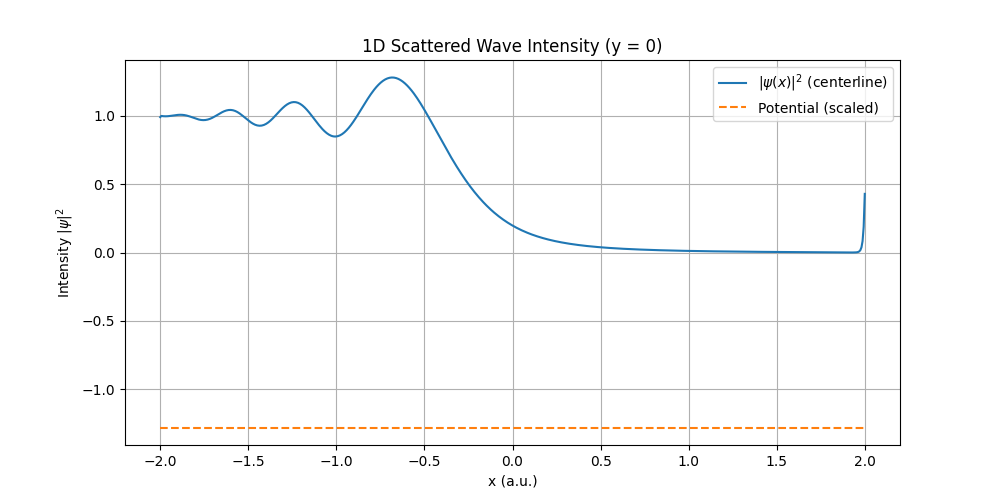

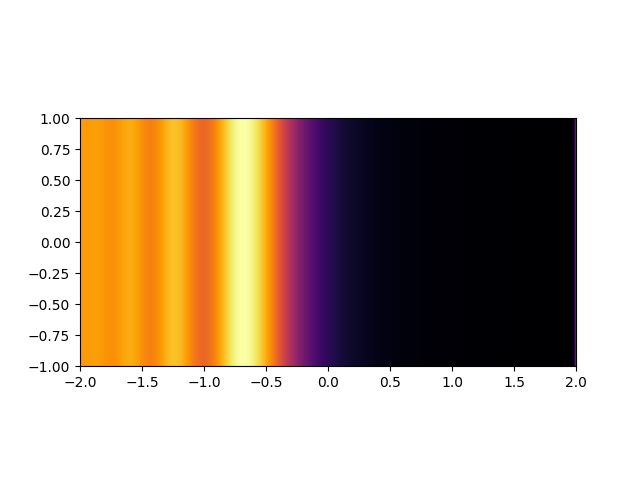

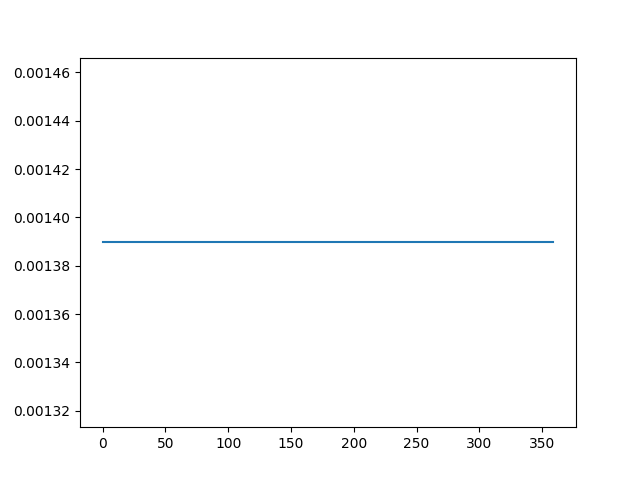

In [4]:
plt.figure()
plt.imshow(intensity, extent=[XMIN, XMAX, YMIN, YMAX], cmap='inferno')

plt.figure()
plt.plot(intensity[:, -50])


# 1D cut through the center (y = 0)
y_center = NY // 2
x = np.linspace(XMIN, XMAX, NX)

plt.figure(figsize=(10,5))
plt.plot(x, intensity[y_center], label=r"$|\psi(x)|^2$ (centerline)")
plt.plot(x, V_map[y_center]/np.max(np.abs(V_map[y_center])) * np.max(intensity[y_center]), '--', label="Potential (scaled)")
plt.xlabel("x (a.u.)")
plt.ylabel("Intensity |$\psi$|$^2$")
plt.title("1D Scattered Wave Intensity (y = 0)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Re-run simulation saving ALL frames for video
N_FRAMES = 600  # Adjust as needed
STEPS_PER_FRAME = 4800
SNAPSHOT_COUNT = N_FRAMES # Save ALL frames so we can animate the evolution

cmd = ["./schrodinger_atomic_cuda", str(N_FRAMES), str(STEPS_PER_FRAME), str(SNAPSHOT_COUNT)]
print("Running Simulation:", ' '.join(cmd))
try:
    result = subprocess.run(cmd, check=True, capture_output=True, text=True)
    print("Simulation Complete.")
except subprocess.CalledProcessError as e:
    print("Error Running Simulation:")
    print(e.stderr)

# Load snapshots
snap_file = 'snapshots.bin'
snapshots = []
print("Loading snapshots...")
with open(snap_file, 'rb') as f:
    nx = np.frombuffer(f.read(4), dtype=np.int32)[0]
    ny = np.frombuffer(f.read(4), dtype=np.int32)[0]
    M = np.frombuffer(f.read(4), dtype=np.int32)[0]
    dt_file = np.frombuffer(f.read(4), dtype=np.float32)[0]
    E_sim_file = np.frombuffer(f.read(4), dtype=np.float32)[0]
    
    for m in range(M):
        t = np.frombuffer(f.read(4), dtype=np.float32)[0]
        phi = np.frombuffer(f.read(nx*ny*4), dtype=np.float32).reshape((ny,nx))
        psi = np.frombuffer(f.read(nx*ny*4), dtype=np.float32).reshape((ny,nx))
        snapshots.append((t, phi, psi))

print(f"Loaded {len(snapshots)} snapshots.")


Running Simulation: ./schrodinger_atomic_cuda 600 4800 600
Simulation Complete.
Loading snapshots...
Loaded 600 snapshots.


In [6]:

# Create Animation of Instantaneous Intensity |psi|^2
import matplotlib.animation as animation

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 6))
# Initial Intensity
t0, phi0, psi0 = snapshots[0]
intensity0 = phi0**2 + psi0**2
im = ax.imshow(intensity0, extent=[XMIN, XMAX, YMIN, YMAX], cmap='magma', animated=True, origin='lower')
ax.set_title("Wavefront Intensity (t=0.00)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label='Intensity $|\\psi|^2$')

def update(frame_idx):
    t, phi, psi = snapshots[frame_idx]
    current_intensity = phi**2 + psi**2
    im.set_array(current_intensity)
    # Update title
    ax.set_title(f"Wavefront Intensity (t={t:.2f})")
    # Optional: Update clim if intensity varies wildly, or keep fixed
    # im.set_clim(vmim=0, vmax=np.max(current_intensity)) 
    return im,

print("Generating Animation...")
ani = animation.FuncAnimation(fig, update, frames=len(snapshots), interval=30, blit=True)

# Save video
video_output = "wavefront_intensity.mp4"
ani.save(video_output, writer='ffmpeg', fps=30, dpi=120)
print(f"Video saved to {video_output}")
plt.close(fig) # Close plot to prevent static display


Generating Animation...
Video saved to wavefront_intensity.mp4


In [7]:
from IPython.display import Video
Video("wavefront_intensity.mp4")

Averaging over the last 120 frames (t = 2.30 to 2.88)...


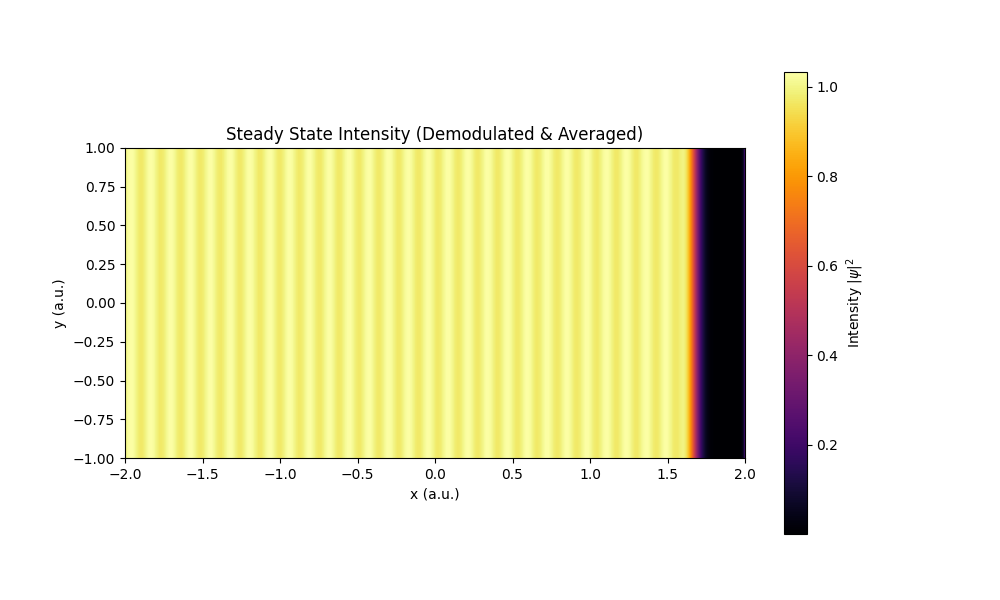

In [8]:
# 4. Extract Steady State Solution (Demodulation)
# To compare with Multislice, we need the time-independent wavefunction psi(x,y).
# We assume Psi(t) ~ psi(x,y) * exp(-i * E * t).
# Therefore, psi(x,y) = Psi(t) * exp(+i * E * t).
# We average over the last 20% of frames to remove noise and ensure transients have passed.

start_avg = int(0.8 * len(snapshots))
subset_snapshots = snapshots[start_avg:]
print(f"Averaging over the last {len(subset_snapshots)} frames (t = {subset_snapshots[0][0]:.2f} to {subset_snapshots[-1][0]:.2f})...")

A_steady = np.zeros_like(snapshots[0][1], dtype=np.complex128)

for t_val, phi_val, psi_val in subset_snapshots:
    # Reconstruct complex wavefunction
    psi_c = phi_val + 1j * psi_val
    # Rotate phase back by exp(+iEt) to cancel time evolution
    phasor = np.exp(1j * E_sim_file * t_val)
    A_steady += psi_c * phasor

A_steady /= len(subset_snapshots)
intensity_steady = np.abs(A_steady)**2

# Plot the Steady State Result
plt.figure(figsize=(10, 6))
plt.imshow(intensity_steady, extent=[XMIN, XMAX, YMIN, YMAX], cmap='inferno', origin='lower')
plt.colorbar(label='Intensity $|\\psi|^2$')
plt.title("Steady State Intensity (Demodulated & Averaged)")
plt.xlabel("x (a.u.)")
plt.ylabel("y (a.u.)")
plt.show()

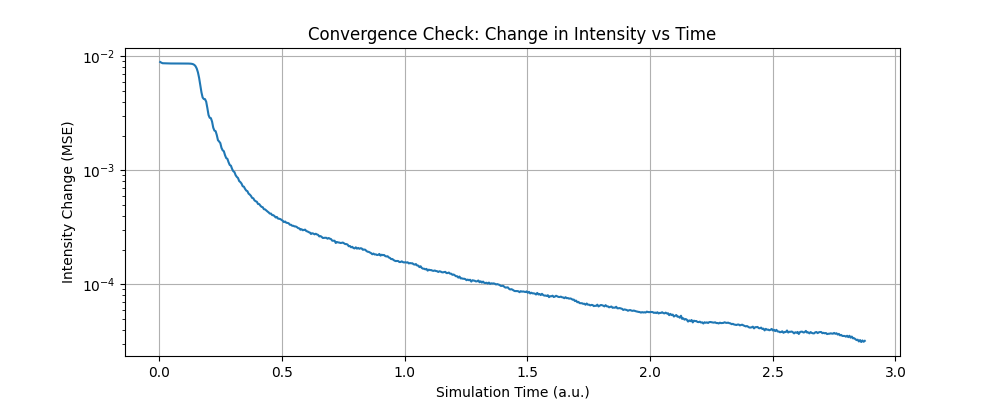

In [9]:
# Check Convergence: Plot the change in Intensity over time
errors = []
times = []

# Skip the first few frames (initial transient)
start_frame = 0 

for i in range(start_frame, len(snapshots)-1):
    t1, phi1, psi1 = snapshots[i]
    t2, phi2, psi2 = snapshots[i+1]
    
    I1 = phi1**2 + psi1**2
    I2 = phi2**2 + psi2**2
    
    # Calculate Mean Squared Error (MSE) between consecutive intensity frames
    mse = np.mean((I2 - I1)**2)
    errors.append(mse)
    times.append(t2)

plt.figure(figsize=(10, 4))
plt.plot(times, errors)
plt.yscale('log')
plt.xlabel("Simulation Time (a.u.)")
plt.ylabel("Intensity Change (MSE)")
plt.title("Convergence Check: Change in Intensity vs Time")
plt.grid(True)
plt.show()